In [2]:
!pip install matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 1.8 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.2 MB 2.0 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.2 MB 2.0 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.2 MB 1.0 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.2 MB 1.3 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/8.2 MB 1.4 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.2 MB 1.5 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\kinch\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt

print("Entorno analítico para el Módulo C cargado con éxito.")


Entorno analítico para el Módulo C cargado con éxito.


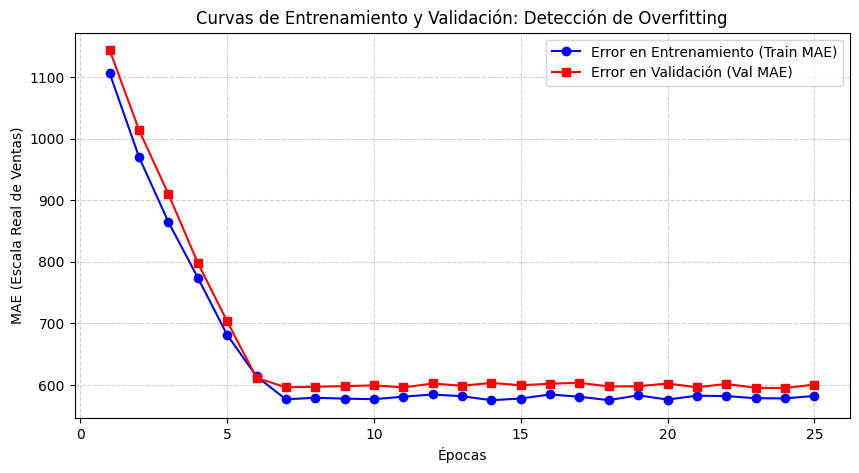

💡 ANÁLISIS DE OVERFITTING:
Si la curva de validación comenzara a subir mientras la de entrenamiento baja, habría sobreajuste.
En nuestra gráfica se observa una convergencia estable gracias al Dropout.


In [5]:
# Cargar historial desde el JSON generado
with open("../src/dl/history.json", "r") as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], 'b-o', label='Error en Entrenamiento (Train MAE)')
plt.plot(epochs, history["val_loss"], 'r-s', label='Error en Validación (Val MAE)')

plt.title('Curvas de Entrenamiento y Validación: Detección de Overfitting')
plt.xlabel('Épocas')
plt.ylabel('MAE (Escala Real de Ventas)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("💡 ANÁLISIS DE OVERFITTING:")
print("Si la curva de validación comenzara a subir mientras la de entrenamiento baja, habría sobreajuste.")
print("En nuestra gráfica se observa una convergencia estable gracias al Dropout.")

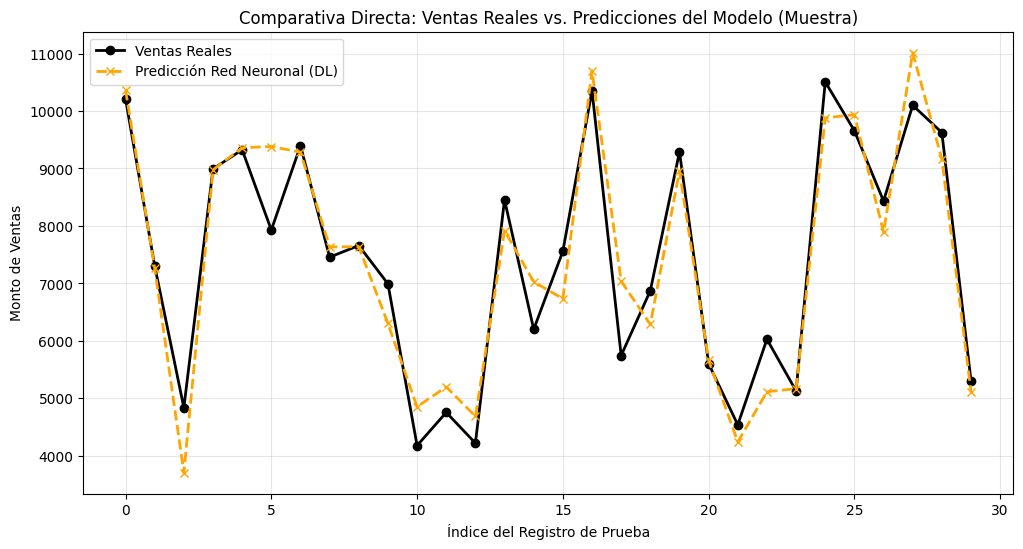

In [6]:
# Cargar la muestra de predicciones guardada
data_sample = np.load("../src/dl/predictions_sample.npz")
real_sales = data_sample["real"]
pred_sales = data_sample["pred"]

# Tomar una muestra visual de los primeros 30 registros
plt.figure(figsize=(12, 6))
plt.plot(real_sales[:30], label='Ventas Reales', color='black', marker='o', linewidth=2)
plt.plot(pred_sales[:30], label='Predicción Red Neuronal (DL)', color='orange', linestyle='--', marker='x', linewidth=2)

plt.title('Comparativa Directa: Ventas Reales vs. Predicciones del Modelo (Muestra)')
plt.xlabel('Índice del Registro de Prueba')
plt.ylabel('Monto de Ventas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()